> Esta revisão apresenta o **Caso 1.2.1: Minimização do Custo Energético em um Cenário de Referência**, estruturado conforme as diretrizes de modelagem matemática e utilizando como base os parâmetros e a lógica de programação contidos nos arquivos de referência.



---

### 1. Caracterização do Modelo

Este é um **Modelo de Otimização Concreto**, implementado através da biblioteca Pyomo. Ao contrário de modelos abstratos que definem a estrutura antes dos dados, o modelo concreto é construído vinculando diretamente os dados de entrada (demandas, geração e custos) aos componentes do modelo (variáveis, restrições e função objetivo) no momento da criação.

### 2. Apresentação do Problema

O problema consiste na gestão energética de uma microrrede composta por:

* **Demanda Comercial e de Eletroposto (EV):** Perfis de carga horários que devem ser supridos integralmente.
* **Geração Fotovoltaica (FV):** Fonte renovável intermitente com capacidade de 50 kWp.
* **Sistema de Armazenamento de Energia por Bateria (BESS):** Utilizado para arbitrar energia (carregar em períodos de baixo custo/excedente e descarregar em picos) e gerenciar o fluxo de potência.
* **Conexão com a Rede Elétrica:** Permite a compra de energia para suprir déficits e a venda de excedentes gerados.

O objetivo central é minimizar o custo total de operação em um horizonte de 24 horas, considerando o custo de compra da rede, a receita de venda e o custo de degradação da bateria (throughput).


O uso do BESS é limitado para valores nos quais exista excedente de energia gerada vs demandado e em defasagens de preços que permitam ganhos econmicos. 

demanda_comercio = [
    14, 14, 14, 14, 17, 21,            # 00h - 05h (Madrugada baixa)
    28, 35, 49, 56, 56, 49,      # 06h - 11h (Subida manhã)
    47, 45, 42, 40, 40, 35,      # 12h - 17h (Tarde alta)
    30, 21, 14, 12, 14, 14        # 18h - 23h (Descida noite)
]

por:


# Média da demanda do comércio (kW)
demanda_comercio_med = 30

# Perfil de demanda / demanda média
demanda_comercio_pu = np.array([
    0.47, 0.47, 0.47, 0.47, 0.57, 0.70,
    0.93, 1.17, 1.63, 1.87, 1.87, 1.63,
    1.57, 1.50, 1.40, 1.33, 1.33, 1.17,
    1.00, 0.70, 0.47, 0.40, 0.47, 0.47
])

# Perfil de demanda do comércio em kW
demanda_comercio = demanda_comercio_pu * demanda_comercio_med
rode o probgrama, é para dar o mesmo resultado que vc tem obtido
se deu o mesmo resultado, reduza a demanda comercial média pela metado, definindo a demanda média como 15 no lugar de 30, e veja no q dá

⏰



### 3. Formulação Matemática

#### 3.1 Conjuntos e Índices

* $T = \{0, 1, ..., 23\}$: Horizonte temporal de 24 horas (discretização horária).

#### 3.2 Parâmetros de Entrada


* $D_{com, t}$: Demanda do comércio no tempo $t$ (kW).

* $D_{ev, t}$: Demanda do eletroposto no tempo $t$ (kW).

* $G_{pv, t}$: Geração fotovoltaica no tempo $t$ (kW).

* $C_{compra}$: Custo unitário de compra da rede (0,75 R$/kWh).

* $P_{venda}$: Preço unitário de venda para a rede (0,40 R$/kWh).

* $C_{deg}$: Custo de degradação da bateria (0,08 R$/kWh).

* $E_{max}$: Capacidade total do BESS (50 kWh).

* $P_{bess, max}$: Potência máxima de carga/descarga (15 kW).

* $\eta_c, \eta_d$: Eficiências de carga e descarga (0,955).

#### 3.3 Variáveis de Decisão


* $p_{grid\_buy, t} \ge 0$: Potência comprada da rede no tempo $t$.

* $p_{grid\_sell, t} \ge 0$: Potência vendida para a rede no tempo $t$.

* $p_{c, t} \in [0, P_{bess, max}]$: Potência de carga do BESS no tempo $t$.

* $p_{d, t} \in [0, P_{bess, max}]$: Potência de descarga do BESS no tempo $t$.

* $SOC_{t}$: Estado de carga da bateria no tempo $t$ (kWh).

#### 3.4 Função Objetivo (F.O.)

Minimizar o custo total operacional ($Z$):


$$Z = \sum_{t \in T} \left( p_{grid\_buy, t} \cdot C_{compra} - p_{grid\_sell, t} \cdot P_{venda} + (p_{c, t} + p_{d, t}) \cdot C_{deg} \right)$$

#### 3.5 Restrições Principais


1. **Balanço de Potência:** Para cada $t$, a soma da geração e compras deve igualar a soma das cargas e vendas:

$G_{pv, t} + p_{grid\_buy, t} + p_{d, t} = D_{com, t} + D_{ev, t} + p_{grid\_sell, t} + p_{c, t}$

2. **Dinâmica do SOC:**

$SOC_{t} = SOC_{t-1} + (p_{c, t} \cdot \eta_c - \frac{p_{d, t}}{\eta_d})$

3. **Limites do SOC:** $0.20 \cdot E_{max} \le SOC_t \le 0.95 \cdot E_{max}$.

### 4. Resultados e Comportamento das Variáveis

Conforme o código de referência, os resultados demonstram:

* **Arbitragem Energética:** O BESS prioriza a carga ($p_{c, t}$) durante picos de geração FV (meio-dia) ou quando a demanda total é inferior à geração disponível.
* **Suprimento de Picos:** A descarga ($p_{d, t}$) ocorre preferencialmente nos horários de pico de demanda do eletroposto (ex: às 13h e 19h), reduzindo a necessidade de compra da rede a custos elevados.
* **Custo de Degradação:** A inclusão de $C_{deg}$ na F.O. impede ciclos desnecessários da bateria, garantindo que ela só opere quando o diferencial entre compra e venda (ou o suprimento da carga) compensar o desgaste físico do equipamento.

### 5. Referências Bibliográficas (ABNT)

> VALLADARES, Letícia Sampaio Drummond. **1.2.1 Caso Referencia - Min Custo Energ**. Arquivo de notebook Jupyter/Colab. 2024. Disponível em: Anexo do projeto



## Código padrão para funcionar os programas.

In [ ]:
# Instalação limpa (apenas o necessário para CBC)
%pip install -q pyomo
!apt-get install -y -qq coinor-cbc

import pyomo.environ as pyo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

'apt-get' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.




---
# Início do Modelo



In [ ]:
# ============================================================
# 3. DEFINIÇÃO DO HORIZONTE TEMPORAL
# ============================================================

HORIZONTE = 24
T = range(HORIZONTE)  # discretização horária

In [ ]:
# ============================================================
# 4. DADOS DE ENTRADA
# ============================================================

# ---------------------------
# 4.1 Demandas (kW)
# ---------------------------

# Demanda do comércio (kW)
# Os valores correspondentes da imagem do Guilherme representam +/- 17kWmédios
# Ajustado com coeficiente 1,74 para que os valores da imagem referencial do Guilherme tenham 30kWmédios
# - Esta adequação para aumentar da demanda médida fez com que a demanda do comércio fosse quase sempre superior a geração FV, ao contrário da imagem do Guilherme
# Média da demanda do comércio (kW)
demanda_comercio_med = 30

# Perfil de demanda / demanda média
demanda_comercio_pu = np.array([
    0.47, 0.47, 0.47, 0.47, 0.57, 0.70,
    0.93, 1.17, 1.63, 1.87, 1.87, 1.63,
    1.57, 1.50, 1.40, 1.33, 1.33, 1.17,
    1.00, 0.70, 0.47, 0.40, 0.47, 0.47
])

# Perfil de demanda do comércio em kW
demanda_comercio = demanda_comercio_pu * demanda_comercio_med
# Demanda do eletroposto (kW)
# Considera 2 carregadores de 50kW (Max 100kW) com dois picos de uso
# Plotado conferindo a imagem de referencia do Guilherme
demanda_ev = [
    0, 0, 0, 0, 0, 0,            # 00h - 05h
    0, 0, 0, 0, 0, 0,      # 06h - 11h (Pico Manhã ~09h)
    72, 96, 72, 0, 0, 00,     # 12h - 17h (Carga leve tarde -> Início Pico)
    76, 100, 76, 0, 0, 0         # 18h - 23h (Pico Noite ~18h e fim)
]

# ---------------------------
# 4.2 Geração Fotovoltaica (kW)
# ---------------------------

# Geração fotovoltaica (kW)
# Compatível com sistema de 50 kWp (Pico ao meio-dia)
geracao_pv = [
    0, 0, 0, 0, 0, 0,            # 00h - 05h (Sem sol)
    2, 12, 28, 42, 48, 50,       # 06h - 11h (Amanhecer até pico)
    50, 48, 42, 28, 12, 2,       # 12h - 17h (Pico até anoitecer)
    0, 0, 0, 0, 0, 0             # 18h - 23h (Sem sol)
]

# ---------------------------
# 4.3 Parâmetros Econômicos
# ---------------------------

custo_compra = 0.75          # R$/kWh
preco_venda = 0.40           # R$/kWh
custo_degradacao = 0.08      # R$/kWh throughput

# ---------------------------
# 4.4 Parâmetros do BESS
# ---------------------------

capacidade_bess = 50.0       # kWh
potencia_max_bess = 15.0     # kW

soc_min = 0.20 * capacidade_bess
soc_max = 0.95 * capacidade_bess
soc_inicial = 0.50 * capacidade_bess

eta_c = 0.955                # eficiência de carga
eta_d = 0.955                # eficiência de descarga

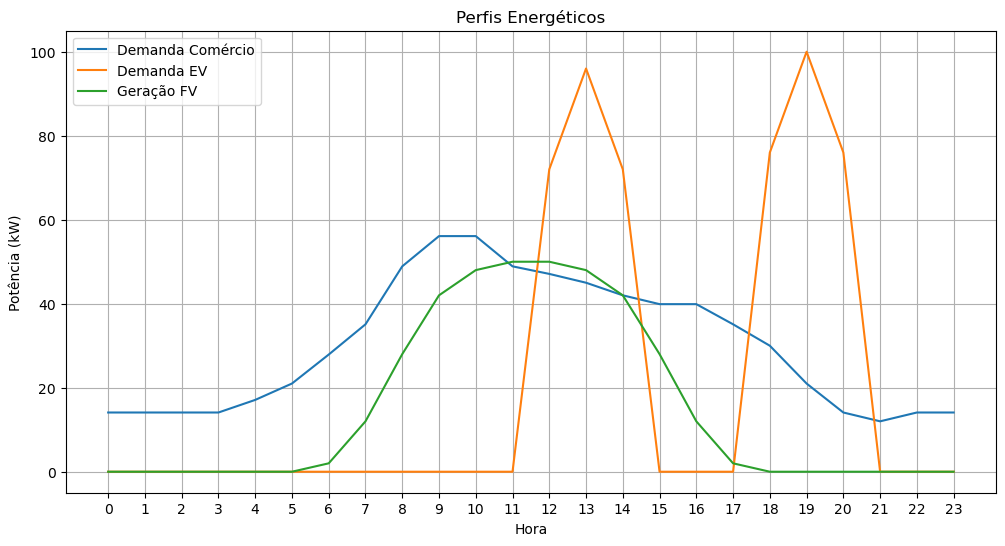

In [ ]:
# ============================================================
# 5. VISUALIZAÇÃO DOS PERFIS
# ============================================================

plt.figure(figsize=(12, 6))
plt.plot(T, demanda_comercio, label="Demanda Comércio")
plt.plot(T, demanda_ev, label="Demanda EV")
plt.plot(T, geracao_pv, label="Geração FV")
plt.xlabel("Hora")
plt.ylabel("Potência (kW)")
plt.title("Perfis Energéticos")
plt.xticks(T)
plt.grid(True)
plt.legend()
plt.show()




---



# Estruturação dos Componentes MILP

In [ ]:
# =========================================================
# 6. CRIAÇÃO DO MODELO DE OTIMIZAÇÃO
# =========================================================

model = pyo.ConcreteModel()
model.T = pyo.Set(initialize=T)

In [ ]:
# ------------------------------------------------------------
# 6.1 Variáveis de decisão
# ------------------------------------------------------------

# -  P_grid : Corresponde a comprar e venda para rede elétrica
model.P_grid = pyo.Var(model.T, domain=pyo.NonNegativeReals)
model.P_export = pyo.Var(model.T, domain=pyo.NonNegativeReals)

# - P_dis/charge : Corresponde ao carregamento da bateria ou pela bateria
model.P_charge = pyo.Var(model.T, domain=pyo.NonNegativeReals)
model.P_discharge = pyo.Var(model.T, domain=pyo.NonNegativeReals)

# - SOC : Estado da bateria
model.SOC = pyo.Var(model.T, domain=pyo.NonNegativeReals)

# - u_charge : Variáveis binárias (bloqueio simultâneo)

model.u_charge = pyo.Var(model.T, domain=pyo.Binary)
model.u_discharge = pyo.Var(model.T, domain=pyo.Binary)

In [ ]:
# ------------------------------------------------------------
# 6.2 Função Objetivo original:
# Minimização do custo total de energia
# ------------------------------------------------------------

def objective_rule(m):
    custo_energia = sum(custo_compra * m.P_grid[t] for t in m.T)
    receita_export = sum(preco_venda * m.P_export[t] for t in m.T)
    custo_deg = sum(custo_degradacao *
                    (m.P_charge[t] + m.P_discharge[t])
                    for t in m.T)
    return custo_energia + custo_deg - receita_export

model.OBJ = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

In [ ]:
# ------------------------------------------------------------
# 6.3 Restrições
# ------------------------------------------------------------

# Balanço de potência horário
def energy_balance_rule(m, t):
    demanda_total = demanda_comercio[t] + demanda_ev[t]
    return (
        m.P_grid[t]
        + geracao_pv[t]
        + m.P_discharge[t]
        ==
        demanda_total
        + m.P_charge[t]
        + m.P_export[t]
    )

model.energy_balance = pyo.Constraint(model.T, rule=energy_balance_rule)

# Dinâmica do SOC
def soc_rule(m, t):
    if t == 0:
        return m.SOC[t] == (
            soc_inicial
            + eta_c * m.P_charge[t]
            - (m.P_discharge[t] / eta_d)
        )
    return m.SOC[t] == (
        m.SOC[t-1]
        + eta_c * m.P_charge[t]
        - (m.P_discharge[t] / eta_d)
    )

model.soc_dyn = pyo.Constraint(model.T, rule=soc_rule)

# Limites operacionais
model.soc_min = pyo.Constraint(model.T,
    rule=lambda m, t: m.SOC[t] >= soc_min)

model.soc_max = pyo.Constraint(model.T,
    rule=lambda m, t: m.SOC[t] <= soc_max)

model.soc_terminal = pyo.Constraint(
    expr=model.SOC[HORIZONTE-1] >= soc_inicial
)

model.charge_limit = pyo.Constraint(
    model.T,
    rule=lambda m, t:
        m.P_charge[t] <= potencia_max_bess * m.u_charge[t]
)

model.discharge_limit = pyo.Constraint(
    model.T,
    rule=lambda m, t:
        m.P_discharge[t] <= potencia_max_bess * m.u_discharge[t]
)

model.no_simultaneous = pyo.Constraint(
    model.T,
    rule=lambda m, t:
        m.u_charge[t] + m.u_discharge[t] <= 1
)



---

# Resoluções Inauteradas

In [ ]:
# ============================================================
# 7. RESOLUÇÃO
# ============================================================

solver = pyo.SolverFactory("gurobi")
results = solver.solve(model, tee=False)

In [ ]:
# ============================================================
# 8. ORGANIZAÇÃO DOS RESULTADOS
# ============================================================

df = pd.DataFrame({
    "Hora": list(T),
    "Demanda_Comercio": demanda_comercio,
    "Demanda_EV": demanda_ev,
    "PV": geracao_pv,
    "Grid": [pyo.value(model.P_grid[t]) for t in T],
    "Export": [pyo.value(model.P_export[t]) for t in T],
    "Carga_BESS": [pyo.value(model.P_charge[t]) for t in T],
    "Descarga_BESS": [pyo.value(model.P_discharge[t]) for t in T],
    "SOC": [pyo.value(model.SOC[t]) for t in T],
})

print(df)
print(f"\nCusto Total: R$ {pyo.value(model.OBJ):.2f}")

    Hora  Demanda_Comercio  Demanda_EV  PV        Grid        Export  \
0      0              14.1           0   0   14.100000  0.000000e+00   
1      1              14.1           0   0   14.100000  0.000000e+00   
2      2              14.1           0   0   14.100000  0.000000e+00   
3      3              14.1           0   0   14.100000  0.000000e+00   
4      4              17.1           0   0   17.100000  0.000000e+00   
5      5              21.0           0   0   21.000000  0.000000e+00   
6      6              27.9           0   2   25.900000  0.000000e+00   
7      7              35.1           0  12   23.100000  0.000000e+00   
8      8              48.9           0  28   20.900000  0.000000e+00   
9      9              56.1           0  42   14.100000  0.000000e+00   
10    10              56.1           0  48    8.100000  0.000000e+00   
11    11              48.9           0  50    0.000000  1.332268e-15   
12    12              47.1          72  50   69.100000  0.000000

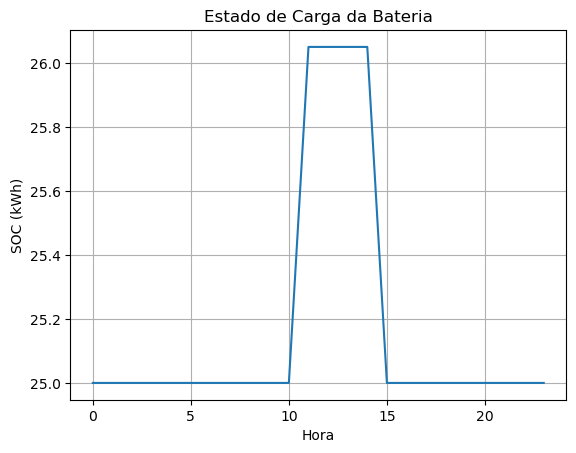

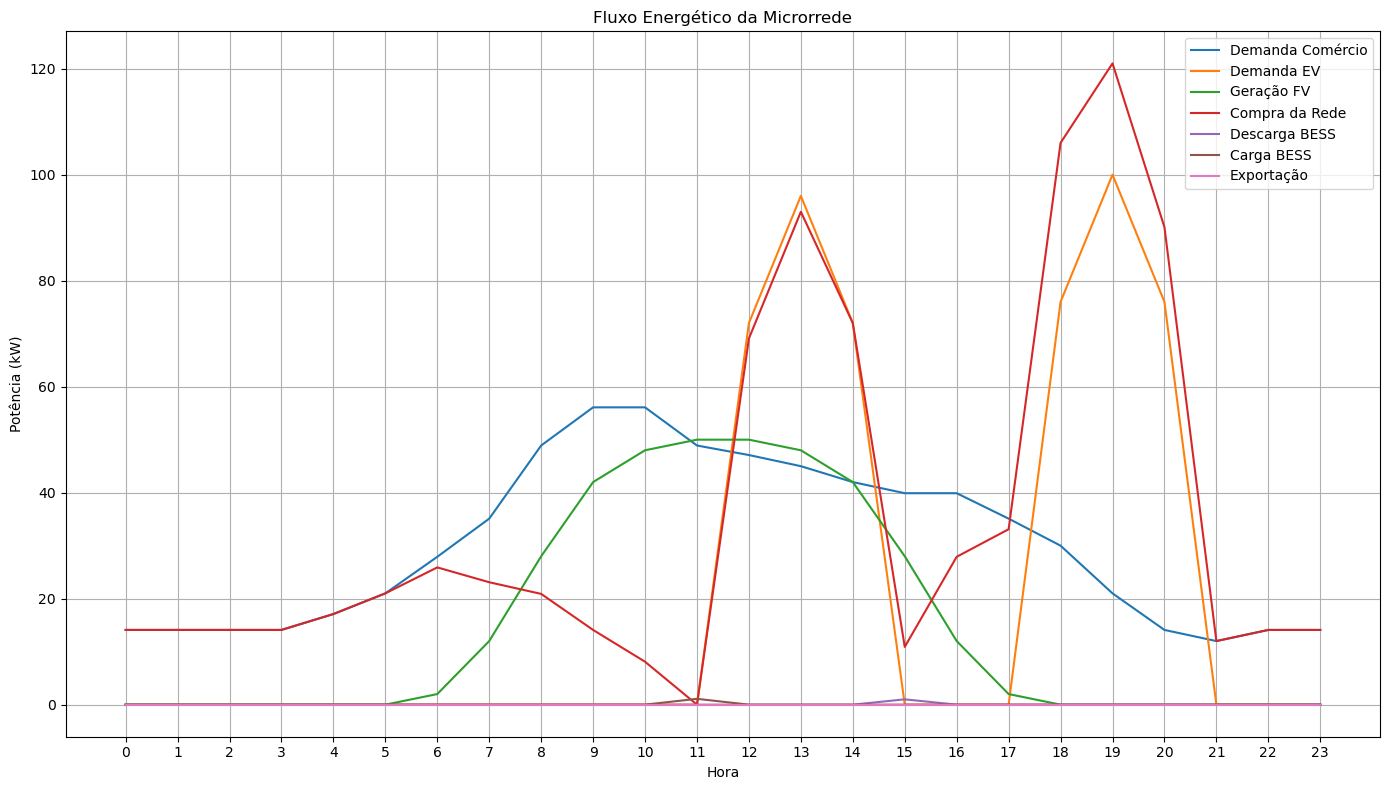

In [ ]:
# ============================================================
# 9. VISUALIZAÇÃO DOS RESULTADOS
# ============================================================

# SOC
plt.figure()
plt.plot(df["Hora"], df["SOC"])
plt.xlabel("Hora")
plt.ylabel("SOC (kWh)")
plt.title("Estado de Carga da Bateria")
plt.grid(True)
plt.show()

# Fluxo energético
plt.figure(figsize=(14, 8))

plt.plot(df["Hora"], df["Demanda_Comercio"], label="Demanda Comércio")
plt.plot(df["Hora"], df["Demanda_EV"], label="Demanda EV")

plt.plot(df["Hora"], df["PV"], label="Geração FV")
plt.plot(df["Hora"], df["Grid"], label="Compra da Rede")
plt.plot(df["Hora"], df["Descarga_BESS"], label="Descarga BESS")
plt.plot(df["Hora"], df["Carga_BESS"], label="Carga BESS")
plt.plot(df["Hora"], df["Export"], label="Exportação")

plt.xlabel("Hora")
plt.ylabel("Potência (kW)")
plt.title("Fluxo Energético da Microrrede")
plt.xticks(df["Hora"])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()